In [1]:
%matplotlib inline

import pandas
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import time
from sklearn.externals import joblib
import Recommenders as Recommenders
import Evaluation as Evaluation
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Steps -

1) Read and explore the given dataset.  ( Rename column/add headers, plot histograms, find data characteristics)

In [2]:
reviews = pd.read_csv('ratings_Electronics.csv')
reviews.columns = ['user_id', 'product_id', 'ratings','timestamp']

In [3]:
reviews.shape

(7824481, 4)

In [4]:
reviews.head()

,user_id,product_id,ratings,timestamp
0,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
1,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
2,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
3,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
4,A1QGNMC6O1VW39,0511189877,5.0,1397433600


In [5]:
#timestamp is of no use to us so let's drop that columns
reviews.drop(columns=['timestamp'],inplace = True)
reviews.head(2)

,user_id,product_id,ratings
0,A2CX7LUOHB2NDG,0321732944,5.0
1,A2NWSAGRHCP8N5,0439886341,1.0


In [6]:
#Histogram of user_id and ratings

C:\Users\Admin\Anaconda3\lib\site-packages\seaborn\categorical.py:3666: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


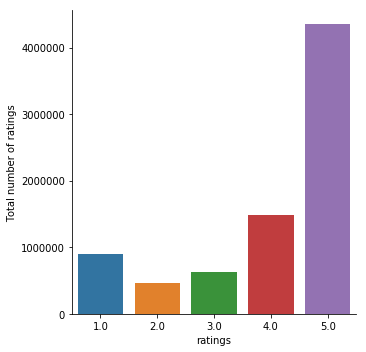

In [59]:
# Check the distribution of ratings 
g = sns.factorplot("ratings", data=reviews, kind='count')
g.set_ylabels("Total number of ratings") 

2) Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [40]:
counts = reviews['user_id'].value_counts()

In [45]:
reviews_short = reviews[reviews['user_id'].isin(counts[counts > 50].index)]

In [49]:
reviews_short.head(2)

,user_id,product_id,ratings
117,AT09WGFUM934H,0594481813,3.0
176,A32HSNCNPRUMTR,0970407998,1.0


In [48]:
reviews_short.shape

(122171, 3)

3) Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)

In [52]:
train_data, test_data = train_test_split(reviews_short, test_size = 0.20, random_state=0)
print(train_data.head(5))

                user_id  product_id  ratings
6625489   AUITG1DJ3QUGK  B009HPC228      5.0
3354083  A3GX0FAMEXV6FB  B003GDF7I8      5.0
1550692  A3AYSYSLHU26U9  B00104XCUU      5.0
5226639  A1BT6TL7UCIC5Y  B005X64M2S      4.0
6711985  A2MOJANFPX353G  B009SPJ3HY      5.0


4) Build Popularity Recommender model.

In [61]:
#Count of user_id for each unique product as recommendation score 
train_data_grouped = train_data.groupby('product_id').agg({'user_id': 'count'}).reset_index()
train_data_grouped.rename(columns = {'user_id': 'score'},inplace=True)
train_data_grouped.head()

,product_id,score
0,0594481813,1
1,0970407998,2
2,0972683275,2
3,1400501466,4
4,1400501520,1


In [62]:
#Sort the products on recommendation score 
train_data_sort = train_data_grouped.sort_values(['score', 'product_id'], ascending = [0,1]) 
      
#Generate a recommendation rank based upon score 
train_data_sort['Rank'] = train_data_sort['score'].rank(ascending=0, method='first') 
          
#Get the top 5 recommendations 
popularity_recommendations = train_data_sort.head(5) 
popularity_recommendations 

,product_id,score,Rank
32948,B0088CJT4U,169,1.0
20944,B003ES5ZUU,148,2.0
9278,B000N99BBC,127,3.0
32319,B007WTAJTO,118,4.0
32626,B00829TIEK,116,5.0


In [55]:
user_id = 'A3AYSYSLHU26U9'  
pm.recommend(user_id)

,user_id,product_id,score,Rank
32948,A3AYSYSLHU26U9,B0088CJT4U,169,1.0
20944,A3AYSYSLHU26U9,B003ES5ZUU,148,2.0
9278,A3AYSYSLHU26U9,B000N99BBC,127,3.0
32319,A3AYSYSLHU26U9,B007WTAJTO,118,4.0
32626,A3AYSYSLHU26U9,B00829TIEK,116,5.0
32622,A3AYSYSLHU26U9,B00829THK0,108,6.0
33233,A3AYSYSLHU26U9,B008DWCRQW,108,7.0
18544,A3AYSYSLHU26U9,B002R5AM7C,101,8.0
24270,A3AYSYSLHU26U9,B004CLYEDC,90,9.0
32663,A3AYSYSLHU26U9,B00834SJNA,84,10.0


In [63]:
# Use popularity based recommender model to make predictions
def recommend(user_id):     
    user_recommendations = popularity_recommendations 
          
    #Add user_id column for which the recommendations are being generated 
    user_recommendations['user_id'] = user_id 
      
    #Bring user_id column to the front 
    cols = user_recommendations.columns.tolist() 
    cols = cols[-1:] + cols[:-1] 
    user_recommendations = user_recommendations[cols] 
          
    return user_recommendations 

5) Build Collaborative Filtering model.

In [64]:
df_CF = pd.concat([train_data, test_data]).reset_index()
df_CF.tail()

,index,user_id,product_id,ratings
122166,1670089,AO09RWV40IX78,B00142HLV4,5.0
122167,7574471,A2LW5AL0KQ9P1M,B00EXPNFQO,3.0
122168,7644257,A6VPK7X53QNAQ,B00FLZ2F5W,3.0
122169,7181156,A2LCE1D0TW2XY0,B00BW6LW7G,4.0
122170,3144845,A2E1EFNIZL2FVA,B0038KV2MO,5.0


In [67]:
#User-based Collaborative Filtering
# Matrix with row per 'user' and column per 'item' 
pivot_df = df_CF.pivot(index = 'user_id', columns ='product_id', values = 'ratings').fillna(0)
print(pivot_df.shape)
pivot_df.head()

(1466, 47155)


product_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
pivot_df['user_index'] = np.arange(0, pivot_df.shape[0], 1)
pivot_df.head()

product_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,...,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8,user_index
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [69]:
pivot_df.set_index(['user_index'], inplace=True)

# Actual ratings given by users
pivot_df.head()

product_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
user_index,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
from scipy.sparse.linalg import svds
# Singular Value Decomposition
U, sigma, Vt = svds(pivot_df, k = 50)
# Construct diagonal array in SVD
sigma = np.diag(sigma)

In [71]:
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) 

# Predicted ratings
preds_df = pd.DataFrame(all_user_predicted_ratings, columns = pivot_df.columns)
preds_df.head()

product_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.001588,0.002451,-0.035895,0.004397,0.006706,0.021698,0.000436,0.008206,0.005558,-0.002057,...,0.000167,-0.058767,0.001375,-0.123896,0.025795,0.015849,0.002735,-0.176885,0.005937,-0.012155
1,-0.011001,0.000095,0.109788,0.010875,-0.003261,0.063178,-0.000852,0.016883,-0.002354,0.026892,...,-0.000023,0.010536,0.001531,0.021341,-0.041795,0.004579,0.002491,-0.026376,-0.018861,0.039145
2,-0.002794,-0.007663,0.007355,0.005759,-0.003735,-0.002737,0.007006,-0.007418,-0.002495,0.005797,...,-0.001553,-0.042050,0.000247,-0.053062,0.018583,-0.005048,-0.002397,0.078739,-0.116666,0.002829
3,0.011624,-0.006947,-0.011842,-0.001235,0.002217,-0.005592,-0.001605,0.002655,0.001673,0.001937,...,0.000576,-0.007289,0.000048,-0.047540,0.022800,0.006261,0.003486,0.005810,-0.017581,-0.025673
4,-0.002654,0.011595,0.020182,0.009237,0.005416,0.016867,0.003852,0.003173,0.005134,0.018685,...,0.000205,0.020602,0.000892,-0.022049,-0.012444,0.001050,0.000947,-0.021427,0.011899,0.013891


In [72]:
# Recommend the items with the highest predicted ratings

def recommend_items(userID, pivot_df, preds_df, num_recommendations):
      
    user_idx = userID-1 # index starts at 0
    
    # Get and sort the user's ratings
    sorted_user_ratings = pivot_df.iloc[user_idx].sort_values(ascending=False)
    #sorted_user_ratings
    sorted_user_predictions = preds_df.iloc[user_idx].sort_values(ascending=False)
    #sorted_user_predictions

    temp = pd.concat([sorted_user_ratings, sorted_user_predictions], axis=1)
    temp.index.name = 'Recommended Items'
    temp.columns = ['user_ratings', 'user_predictions']
    
    temp = temp.loc[temp.user_ratings == 0]   
    temp = temp.sort_values('user_predictions', ascending=False)
    print('\nBelow are the recommended items for user(user_id = {}):\n'.format(userID))
    print(temp.head(num_recommendations))

In [75]:
#Enter 'userID' and 'num_recommendations' for the user #
userID = 125
num_recommendations = 5
recommend_items(userID, pivot_df, preds_df, num_recommendations)


Below are the recommended items for user(user_id = 125):

                   user_ratings  user_predictions
Recommended Items                                
B001XURP7W                  0.0          0.411329
B001TH7GUU                  0.0          0.331005
B0019EHU8G                  0.0          0.324463
B002WE6D44                  0.0          0.305069
B000VX6XL6                  0.0          0.304259


C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  del sys.path[0]


Q6. Evaluate both the models. 

In [78]:
final_ratings_matrix = reviews_short.pivot(index = 'user_id', columns ='product_id', values = 'ratings').fillna(0)
print('Shape of final_ratings_matrix: ', final_ratings_matrix.shape)

given_num_of_ratings = np.count_nonzero(final_ratings_matrix)
print('given_num_of_ratings = ', given_num_of_ratings)
possible_num_of_ratings = final_ratings_matrix.shape[0] * final_ratings_matrix.shape[1]
print('possible_num_of_ratings = ', possible_num_of_ratings)
density = (given_num_of_ratings/possible_num_of_ratings)
density *= 100
print ('density: {:4.2f}%'.format(density))

Shape of final_ratings_matrix:  (1466, 47155)
given_num_of_ratings =  122171
possible_num_of_ratings =  69129230
density: 0.18%


In [79]:
# Actual ratings given by the users
final_ratings_matrix.head()

product_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
# Average ACTUAL rating for each item
final_ratings_matrix.mean().head()

product_id
0594481813    0.002046
0970407998    0.003411
0972683275    0.010232
1400501466    0.010232
1400501520    0.003411
dtype: float64

In [81]:
# Predicted ratings 
preds_df.head()

product_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.001588,0.002451,-0.035895,0.004397,0.006706,0.021698,0.000436,0.008206,0.005558,-0.002057,...,0.000167,-0.058767,0.001375,-0.123896,0.025795,0.015849,0.002735,-0.176885,0.005937,-0.012155
1,-0.011001,0.000095,0.109788,0.010875,-0.003261,0.063178,-0.000852,0.016883,-0.002354,0.026892,...,-0.000023,0.010536,0.001531,0.021341,-0.041795,0.004579,0.002491,-0.026376,-0.018861,0.039145
2,-0.002794,-0.007663,0.007355,0.005759,-0.003735,-0.002737,0.007006,-0.007418,-0.002495,0.005797,...,-0.001553,-0.042050,0.000247,-0.053062,0.018583,-0.005048,-0.002397,0.078739,-0.116666,0.002829
3,0.011624,-0.006947,-0.011842,-0.001235,0.002217,-0.005592,-0.001605,0.002655,0.001673,0.001937,...,0.000576,-0.007289,0.000048,-0.047540,0.022800,0.006261,0.003486,0.005810,-0.017581,-0.025673
4,-0.002654,0.011595,0.020182,0.009237,0.005416,0.016867,0.003852,0.003173,0.005134,0.018685,...,0.000205,0.020602,0.000892,-0.022049,-0.012444,0.001050,0.000947,-0.021427,0.011899,0.013891


In [82]:
# Average PREDICTED rating for each item
preds_df.mean().head()

product_id
0594481813    0.002948
0970407998    0.003437
0972683275    0.009239
1400501466    0.004098
1400501520    0.001890
dtype: float64

In [83]:
rmse_df = pd.concat([final_ratings_matrix.mean(), preds_df.mean()], axis=1)
rmse_df.columns = ['Avg_actual_ratings', 'Avg_predicted_ratings']
print(rmse_df.shape)
rmse_df['item_index'] = np.arange(0, rmse_df.shape[0], 1)
rmse_df.head()

(47155, 2)


,Avg_actual_ratings,Avg_predicted_ratings,item_index
product_id,,,
0594481813,0.002046,0.002948,0
0970407998,0.003411,0.003437,1
0972683275,0.010232,0.009239,2
1400501466,0.010232,0.004098,3
1400501520,0.003411,0.001890,4


In [84]:
RMSE = round((((rmse_df.Avg_actual_ratings - rmse_df.Avg_predicted_ratings) ** 2).mean() ** 0.5), 5)
print('\nRMSE SVD Model = {} \n'.format(RMSE))


RMSE SVD Model = 0.00285 



 Q7. Get top - K ( K = 5) recommendations. 

In [86]:
## Enter 'userID' and 'num_recommendations' for the user #
userID = 200
num_recommendations = 5
recommend_items(userID, pivot_df, preds_df, num_recommendations)


Below are the recommended items for user(user_id = 200):

                   user_ratings  user_predictions
Recommended Items                                
B0088CJT4U                  0.0          0.900405
B002R5AM7C                  0.0          0.742282
B00829TIA4                  0.0          0.572265
B004CLYEDC                  0.0          0.506008
B003CFATT2                  0.0          0.457608


C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  del sys.path[0]


8) Summarise your insights.

In [74]:
# Model-based Collaborative Filtering is a personalised recommender system

# The Popularity-based recommender system is non-personalised and the recommendations are based on frequecy counts

# The Popularity based model has recommended the same set of 5 products to all users
# The Collaborative Filtering based model has recommended different list for esch user based on the user past purchase history